# Lab 19: UMAP dimensionality reduction

Built-in digits: 1,797 rows, 64 features. Manageable sample, not production-scale. Unsupervised UMAP fit only on training data; labels are used for coloring/evaluation, not fitting. Compares held-out 5-NN before/after reduction and training neighborhood trustworthiness.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


Dataset shape: (1797, 64)
Reduced shape: (1347, 2)
Training trustworthiness (10 neighbors): 0.9755448262519093
Original-space KNN test accuracy: 0.9644444444444444
UMAP-space KNN test accuracy: 0.9577777777777777


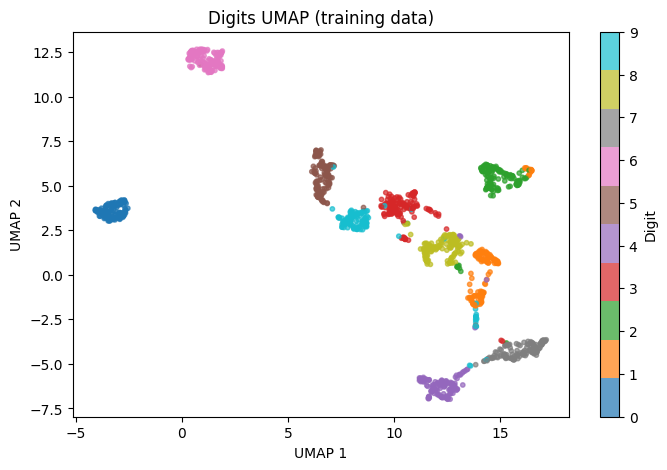

In [2]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.manifold import trustworthiness
import umap
D=load_digits();X_train,X_test,y_train,y_test=train_test_split(D.data,D.target,test_size=.25,random_state=42,stratify=D.target)
scaler=StandardScaler();A=scaler.fit_transform(X_train);B=scaler.transform(X_test)
reducer=umap.UMAP(n_components=2,n_neighbors=15,min_dist=.1,random_state=42,n_jobs=1);Z_train=reducer.fit_transform(A);Z_test=reducer.transform(B)
base=KNeighborsClassifier(n_neighbors=5).fit(A,y_train);reduced=KNeighborsClassifier(n_neighbors=5).fit(Z_train,y_train)
print('Dataset shape:',D.data.shape);print('Reduced shape:',Z_train.shape);print('Training trustworthiness (10 neighbors):',trustworthiness(A,Z_train,n_neighbors=10));print('Original-space KNN test accuracy:',accuracy_score(y_test,base.predict(B)));print('UMAP-space KNN test accuracy:',accuracy_score(y_test,reduced.predict(Z_test)))
plt.figure(figsize=(8,5));plt.scatter(Z_train[:,0],Z_train[:,1],c=y_train,cmap='tab10',s=10,alpha=.7);plt.title('Digits UMAP (training data)');plt.xlabel('UMAP 1');plt.ylabel('UMAP 2');plt.colorbar(label='Digit');plt.show()
